In [73]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import *

In [74]:
df=pd.read_csv('day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [75]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [76]:
X = df.drop(["cnt","dteday"], axis=1)
y = df["cnt"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(max_depth=10,random_state=42)
model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [77]:
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print("Train MSE:", mean_squared_error(y_train, train_pred))
print("Test MSE:", mean_squared_error(y_test, test_pred))

Train MSE: 510.94679957599476
Test MSE: 35643.25226407914


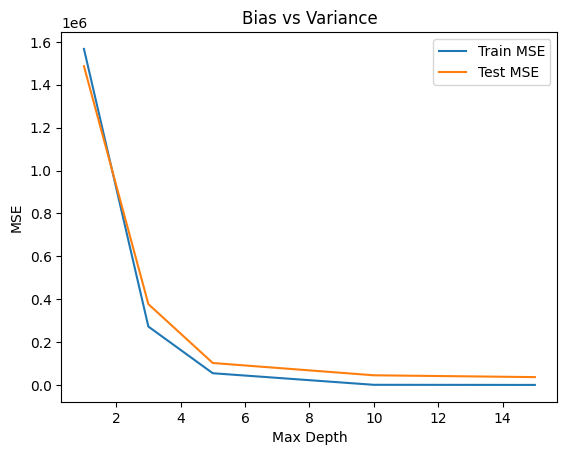

In [78]:
from sklearn.metrics import mean_squared_error

depths = [1, 3, 5, 10, 15]

train_mse = []
test_mse = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d)
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_mse.append(mean_squared_error(y_train, train_pred))
    test_mse.append(mean_squared_error(y_test, test_pred))

plt.plot(depths, train_mse, label="Train MSE")
plt.plot(depths, test_mse, label="Test MSE")
plt.xlabel("Max Depth")
plt.ylabel("MSE")
plt.legend()
plt.title("Bias vs Variance")
plt.show()

Depth vs MSE
👉 What you should SEE:
Train error ↓
Test error ↓ then ↑

👉 Lowest point = best depth

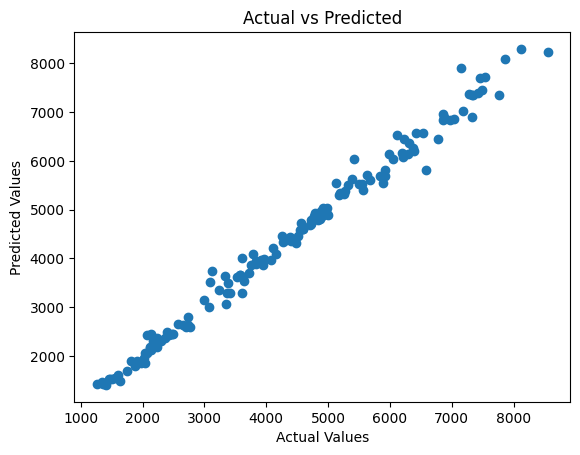

In [79]:
plt.scatter(y_test, test_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

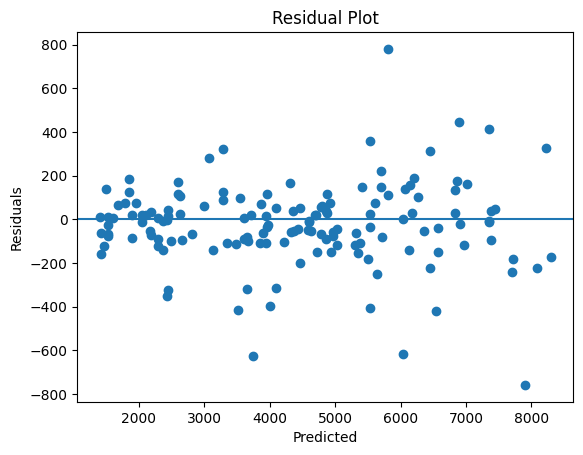

In [80]:
residuals = y_test - test_pred

plt.scatter(test_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()